# DPointNet tutorial with V1 network

This notebook introduces dpointnet with networks that respond to visual stimuli, along the lines of models of the mouse primary visual cortex (area V1), such as those reported in [Billeh et al. (2020)](https://doi.org/10.1016/j.neuron.2020.01.040) and, especially, [Ito et al. (2026)](https://doi.org/10.64898/2026.03.13.711751). The first section uses a 200-um radius cutout from the larger V1 model, corresponding to cortical layer 4 (L4), driven by LGN inputs in response to drifting gratings. It demonstrates how one can tune the connection weights to minimize loss functions. We define a few different firing-rate loss functions to see how they affect network spikes (as seen in raster plots) and firing-rate distributions. The second section runs the full V1 network for 0 and 180 degree drifting gratings, and adds a non-trivial layer 5 (L5) spatial-bias loss function.

This tutorial focuses on examples of specific applications of DPointNet. For more information on DPointNet configuration files and creating simulations of your own, see [Chapter 7.1: Introduction to DPointNet](../Ch7.1_introduction/7.1_DPointNet_Intro.ipynb).

## What DPointNet gives us

DPointNet provides a simulator that runs SONATA-formatted point-neuron networks with GLIF3 models. The DPointNet simulator contains both the module that processes input (analogous to FilterNet in conventional BMTK simulations) and the module that processes the recurrent network (similar to the older PointNet module). The network receives stimulus-driven LGN spikes and background input, then produces V1 spikes and voltages. The simulations are run on GPUs when available using TensorFlow as the backend. The entire simulation is differentiable; we can train selected synaptic weights with losses defined on firing rates, membrane voltage, and weight distributions. In this tutorial the trainable weights are V1-to-V1 recurrent weights and background input weights; LGN stimulus weights stay fixed.


## Setup

Run this notebook with an environment that has a GPU and TensorFlow available. The tutorial folder already contains the V1 network files, Neuropixels firing-rate targets, synchronization data, JSON config files, and the small `run_dpointnet.py` runner script used by the examples.

Set `RUN_SIMULATIONS = False` when you only want to just replot results that you already generated.

Some plotting utilities live in `workshop_dpointnet.py`; the simulator setup itself stays in the config files and runner script.

In [1]:
from pathlib import Path
import importlib
import os
import subprocess
import sys

import pandas as pd
import matplotlib.pyplot as plt

import workshop_dpointnet as ws
ws = importlib.reload(ws)

RUN_SIMULATIONS = True

# Setting up a function to run the configuration file
def run_config(config_file):
    command = [sys.executable, 'run_dpointnet.py', str(config_file)]
    print('$ ' + ' '.join(command))
    subprocess.run(command, check=True)


print(f'Working directory: {Path.cwd()}')
print('Set RUN_SIMULATIONS = False if you only want to inspect existing outputs.')

I0000 00:00:1784141039.582319 1515084 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784141039.619815 1515084 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Working directory: /local2/tf_tutorial/bmtk-workshop/Ch7_dpointnet/Ch7.2_v1_examples
Set RUN_SIMULATIONS = False if you only want to inspect existing outputs.


## Network files

The full V1 example network is available online to download (link: https://brain-map.org/our-research/computational-modeling/differentiable-biorealistic-v1-model-resources; Follow 'Prebuilt SONATA network download' link). The first section uses a 200-um radius L4 cutout derived from the downloaded full V1 network. The L4 and full V1 networks have the same basic structure (LGN, BKG, recurrent networks), so the DPointNet config structure works for both networks with small changes.

The cutout keeps only layer 4 within a 200-µm radius, making the Part 1 exercises faster and easier to inspect. In Part 2, we scale the same simulation and training workflow to the 400-µm-radius full V1 network with all five modeled cortical layers.

<img src="images/v1_network_scales.png" alt="Comparison of the layer 4 cutout and full V1 network" width="850">

In [2]:
l4_metadata = ws.create_l4_cutout_network(
    source_dir='GLIF_network/network',
    target_dir='GLIF_network_l4_cutout/network',
    radius=200.0,
    overwrite=False,
)

print(f"L4 cutout ready: {len(l4_metadata)} neurons")

L4 cutout ready: 4838 neurons


In [3]:
l4_metadata = ws.load_v1_metadata('GLIF_network_l4_cutout/network')

cutout_summary = pd.DataFrame([{
    'network_dir': 'GLIF_network_l4_cutout/network',
    'n_neurons': len(l4_metadata),
    'n_cell_types': l4_metadata['cell_type'].nunique(),
}])

display(cutout_summary)
display(l4_metadata.head())
display(l4_metadata.groupby('cell_type').size().rename('n_neurons'))

,network_dir,n_neurons,n_cell_types
0,GLIF_network_l4_cutout/network,4838,4


,node_id,node_type_id,pop_name,layer,cell_type,x,z
0,0,354833767,e4Nr5a1,L4,L4 Exc,113.788498,-85.973984
1,1,354833767,e4Nr5a1,L4,L4 Exc,-80.400063,19.220135
2,2,354833767,e4Nr5a1,L4,L4 Exc,-25.938204,-179.643661
3,3,354833767,e4Nr5a1,L4,L4 Exc,2.425989,116.489807
4,4,354833767,e4Nr5a1,L4,L4 Exc,198.661758,13.519364


cell_type
L4 Exc    4298
L4 PV      288
L4 SST     172
L4 VIP      80
Name: n_neurons, dtype: int64

## Training small L4 cutout network

Let's use a 0 degree drifting grating stimulus passed through the LGN network, plus spontaneous background with a constant firing rate of 250 Hz. First, we want to run a simulation without training the network, to see the evoked response of the untrained, plain network. Second, we will train the network to target a single-valued firing rate for all neurons. Third, we will match the overall firing rate distribution to what's observed in the Neuropixels data. Finally, we will match the firing rate distribution for each cell type (Exc, PV, SST, VIP) separately.


### Plain L4 network

First we run the untrained L4 cutout with the 0 degree LGN stimulus and background input. This gives the baseline evoked firing-rate distribution before any weights are trained. The intro runs for 1000 ms, so each neuron's firing rate falls in 1 Hz increments. The raster plot shows every neuron in the cutout, colored by cell type: excitatory in red, PV in green, SST in blue, and VIP in purple.

Running this cell for the first time will take several minutes to create LGN filter cache.

$ /local2/mmroot/envs/dpnet/bin/python run_dpointnet.py configs/config.l4.inference.plain.json


I0000 00:00:1784141042.965417 1515146 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784141042.999633 1515146 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-15 11:44:05,844 [WARNING] Directory ./output_intro_l4_plain already exists.
2026-07-15 11:44:05,844 [INFO] Created log file
2026-07-15 11:44:05,844 [INFO] TensorFlow precision policy set to "mixed_float16" (compute_dtype=float16, variable_dtype=float32, requested_dtype=float16).


I0000 00:00:1784141046.190525 1515146 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1784141046.190775 1515146 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22437 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:65:00.0, compute capability: 8.6


2026-07-15 11:44:06,389 [INFO] Building "lgn_dg0" inputs for lgn
2026-07-15 11:44:06,486 [INFO] Building "bkg_random" inputs for bkg
2026-07-15 11:44:06,486 [INFO] RNN.run() starting...
2026-07-15 11:44:06,486 [INFO] Building Model.


E0000 00:00:1784141047.387084 1515146 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


2026-07-15 11:44:08,696 [INFO] Running Inference on Model (inference).


I0000 00:00:1784141048.740229 1515146 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1784141049.058314 1515337 service.cc:153] XLA service 0x7f55ec0f6070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784141049.058335 1515337 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3090, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.23.1)
I0000 00:00:1784141049.063498 1515337 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784141049.070196 1515337 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1784141049.166636 1515337 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2026-07-15 11:44:57,647 [INFO] Saving Results to file.
2026-07-15 11:44:57,686 [INFO] RNN.run() completed.
Finished configs/config.l4.inference.plain.json in 0.87 min
Spike count: 12161


,count,mean,median,std
firing_rate_hz,4838.0,2.513642,1.0,4.394694


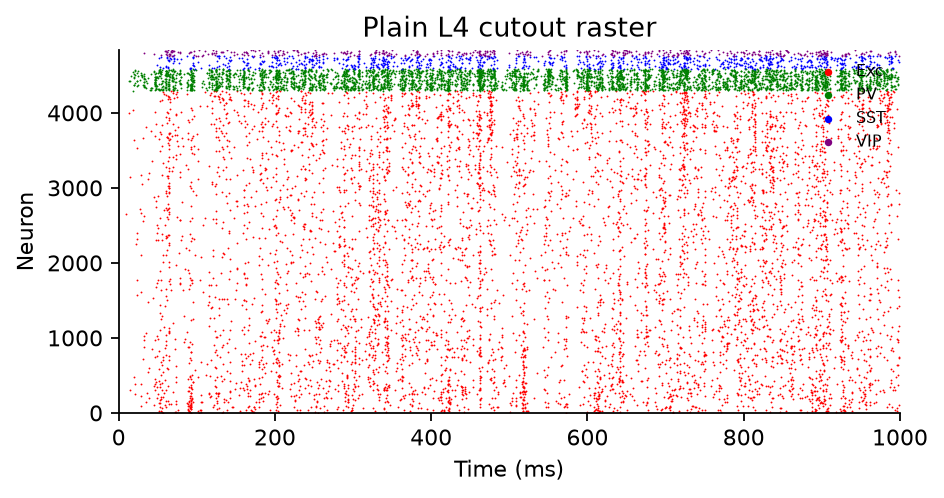

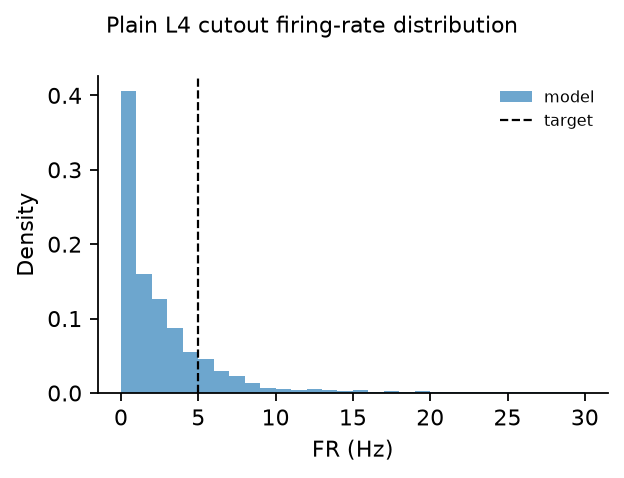

In [4]:
if RUN_SIMULATIONS:
    run_config('configs/config.l4.inference.plain.json')
else:
    print('Skipping plain L4 inference. Set RUN_SIMULATIONS = True to run it.')

plain_rates = ws.plot_intro_result(
    'output_intro_l4_plain/spikes.h5',
    network_dir='GLIF_network_l4_cutout/network',
    t_stop=1000.0,
    title='Plain L4 cutout',
    target_rate=5.0,
)

### Training to one target firing rate

The simulation works, but the firing rates of the untrained network are a bit lower than the desired 5 Hz. The first training objective is intentionally simple: pull every neuron toward 5 Hz. This is easy to understand, but it is not biologically realistic. After training, compare the raster and histogram with the baseline and notice how a single scalar target can make the firing-rate distribution too narrow.


$ /local2/mmroot/envs/dpnet/bin/python run_dpointnet.py configs/config.l4.training.uniform_rate.json


I0000 00:00:1784141099.423804 1515843 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784141099.457705 1515843 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-15 11:45:02,285 [WARNING] Directory ./output_intro_l4_uniform_rate already exists.
2026-07-15 11:45:02,285 [INFO] Created log file
2026-07-15 11:45:02,286 [INFO] TensorFlow precision policy set to "mixed_float16" (compute_dtype=float16, variable_dtype=float32, requested_dtype=float16).


I0000 00:00:1784141102.615095 1515843 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1784141102.615347 1515843 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22437 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:65:00.0, compute capability: 8.6


2026-07-15 11:45:02,815 [INFO] Building "lgn_dg0" inputs for lgn
2026-07-15 11:45:02,914 [INFO] Building "bkg_random" inputs for bkg
2026-07-15 11:45:02,920 [INFO] RNN.run() starting...
2026-07-15 11:45:02,920 [INFO] Building Model.


E0000 00:00:1784141103.824906 1515843 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


2026-07-15 11:45:05,120 [INFO] Training Model.
2026-07-15 11:45:05,126 [INFO] > Training Started @ 15-07-2026 11:45
2026-07-15 11:45:05,127 [INFO] >> Epoch 1/3 Started @ 15-07-2026 11:45


I0000 00:00:1784141105.171161 1515843 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1784141105.467567 1516002 service.cc:153] XLA service 0x7fd79c0f5d70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784141105.467587 1516002 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3090, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.23.1)
I0000 00:00:1784141105.472587 1516002 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784141105.479231 1516002 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1784141105.575406 1516002 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2026-07-15 11:45:25,357 [INFO] >>> Epoch  1/ 3, Step  1/20 (run time: 20.20 s, Rate: 0.0025)
2026-07-15 11:45:25,357 [INFO] >>>   Loss: 25.4688 (dg0:  25.4688)
2026-07-15 11:45:25,379 [INFO] >>>   "GPU:0" Memory Used:   2.61 GiB, Free  21.08 GiB, Total  24.00 GiB.
2026-07-15 11:45:28,032 [INFO] >>> Epoch  1/ 3, Step  2/20 (run time: 2.63 s, Rate: 0.0026)
2026-07-15 11:45:28,032 [INFO] >>>   Loss: 24.4062 (dg0:  24.4062)
2026-07-15 11:45:28,055 [INFO] >>>   "GPU:0" Memory Used:   2.86 GiB, Free  20.83 GiB, Total  24.00 GiB.
2026-07-15 11:45:30,706 [INFO] >>> Epoch  1/ 3, Step  3/20 (run time: 2.62 s, Rate: 0.0029)
2026-07-15 11:45:30,706 [INFO] >>>   Loss: 23.8906 (dg0:  23.8906)
2026-07-15 11:45:30,728 [INFO] >>>   "GPU:0" Memory Used:   2.96 GiB, Free  20.73 GiB, Total  24.00 GiB.
2026-07-15 11:45:33,382 [INFO] >>> Epoch  1/ 3, Step  4/20 (run time: 2.63 s, Rate: 0.0030)
2026-07-15 11:45:33,382 [INFO] >>>   Loss: 22.5469 (dg0:  22.5469)
2026-07-15 11:45:33,403 [INFO] >>>   "GPU:0" Mem

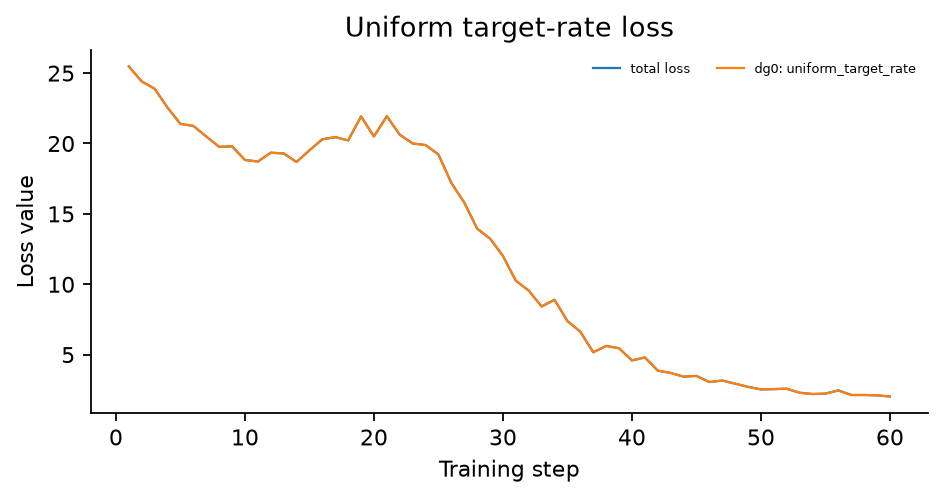

Spike count: 24248


,count,mean,median,std
firing_rate_hz,4838.0,5.011988,5.0,1.376078


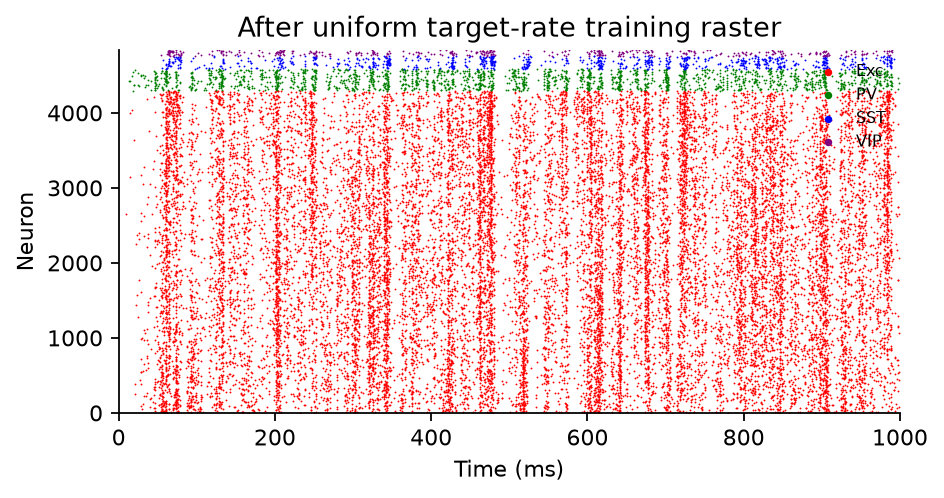

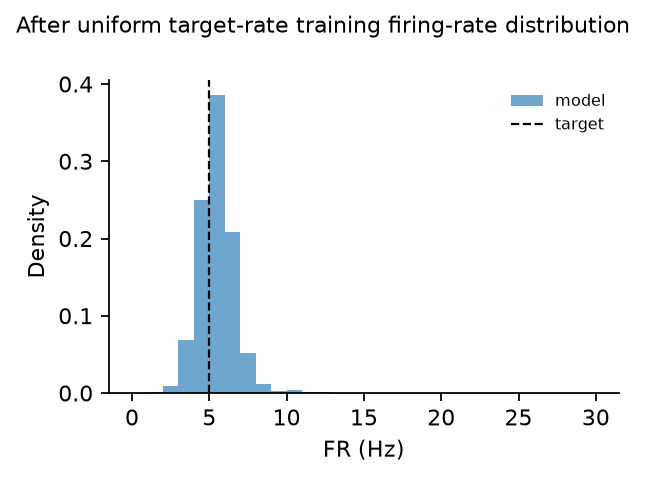

In [5]:
if RUN_SIMULATIONS:
    run_config('configs/config.l4.training.uniform_rate.json')
else:
    print('Skipping uniform-rate training. Set RUN_SIMULATIONS = True to run it.')

ws.plot_loss_if_exists('training_callbacks_intro_l4_uniform_rate/losses.csv', 'Uniform target-rate loss')

uniform_rates = ws.plot_intro_result(
    'output_intro_l4_uniform_rate/spikes.h5',
    network_dir='GLIF_network_l4_cutout/network',
    t_stop=1000.0,
    title='After uniform target-rate training',
    target_rate=5.0,
)

### Distribution-matching loss

The next config compares sorted model firing rates with firing rates sampled from the Neuropixels distribution. The custom loss function for this purpose is registered by `tutorial_losses.py`, which is imported by `run_dpointnet.py`. Please see these files to learn how to make and set up custom loss functions.

### Matching the overall Neuropixels distribution

A single target rate ignores the variability between neurons seen in real cortical recordings. Here we compare the model with the Neuropixels firing-rate distribution and train the model to match that overall distribution. This is a better objective than one fixed rate, but it still does not guarantee that each modeled cell type has the right firing-rate distribution.


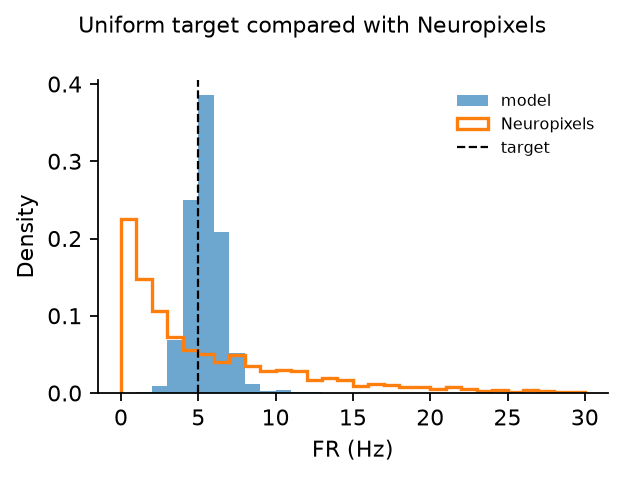

$ /local2/mmroot/envs/dpnet/bin/python run_dpointnet.py configs/config.l4.training.overall_distribution.json


I0000 00:00:1784141328.434012 1517258 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784141328.468034 1517258 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-15 11:48:51,303 [WARNING] Directory ./output_intro_l4_overall_distribution already exists.
2026-07-15 11:48:51,303 [INFO] Created log file
2026-07-15 11:48:51,304 [INFO] TensorFlow precision policy set to "mixed_float16" (compute_dtype=float16, variable_dtype=float32, requested_dtype=float16).


I0000 00:00:1784141331.626192 1517258 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1784141331.626438 1517258 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22437 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:65:00.0, compute capability: 8.6


2026-07-15 11:48:51,824 [INFO] Building "lgn_dg0" inputs for lgn
2026-07-15 11:48:51,922 [INFO] Building "bkg_random" inputs for bkg
2026-07-15 11:48:52,068 [INFO] RNN.run() starting...
2026-07-15 11:48:52,068 [INFO] Building Model.


E0000 00:00:1784141332.950391 1517258 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


2026-07-15 11:48:54,245 [INFO] Training Model.
2026-07-15 11:48:54,251 [INFO] > Training Started @ 15-07-2026 11:48
2026-07-15 11:48:54,253 [INFO] >> Epoch 1/3 Started @ 15-07-2026 11:48


I0000 00:00:1784141334.297328 1517258 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1784141334.594365 1517424 service.cc:153] XLA service 0x7f85180f6070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784141334.594385 1517424 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3090, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.23.1)
I0000 00:00:1784141334.599481 1517424 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784141334.606116 1517424 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1784141334.702878 1517424 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2026-07-15 11:49:14,607 [INFO] >>> Epoch  1/ 3, Step  1/20 (run time: 20.32 s, Rate: 0.0050)
2026-07-15 11:49:14,607 [INFO] >>>   Loss: 4.3956 (dg0:   4.3956)
2026-07-15 11:49:14,629 [INFO] >>>   "GPU:0" Memory Used:   2.67 GiB, Free  21.01 GiB, Total  24.00 GiB.
2026-07-15 11:49:17,262 [INFO] >>> Epoch  1/ 3, Step  2/20 (run time: 2.61 s, Rate: 0.0050)
2026-07-15 11:49:17,262 [INFO] >>>   Loss: 4.2968 (dg0:   4.2968)
2026-07-15 11:49:17,272 [INFO] >>>   "GPU:0" Memory Used:   2.74 GiB, Free  20.95 GiB, Total  24.00 GiB.
2026-07-15 11:49:19,882 [INFO] >>> Epoch  1/ 3, Step  3/20 (run time: 2.58 s, Rate: 0.0051)
2026-07-15 11:49:19,883 [INFO] >>>   Loss: 4.3696 (dg0:   4.3696)
2026-07-15 11:49:19,904 [INFO] >>>   "GPU:0" Memory Used:   2.77 GiB, Free  20.92 GiB, Total  24.00 GiB.
2026-07-15 11:49:22,539 [INFO] >>> Epoch  1/ 3, Step  4/20 (run time: 2.61 s, Rate: 0.0050)
2026-07-15 11:49:22,539 [INFO] >>>   Loss: 4.1792 (dg0:   4.1792)
2026-07-15 11:49:22,561 [INFO] >>>   "GPU:0" Memory 

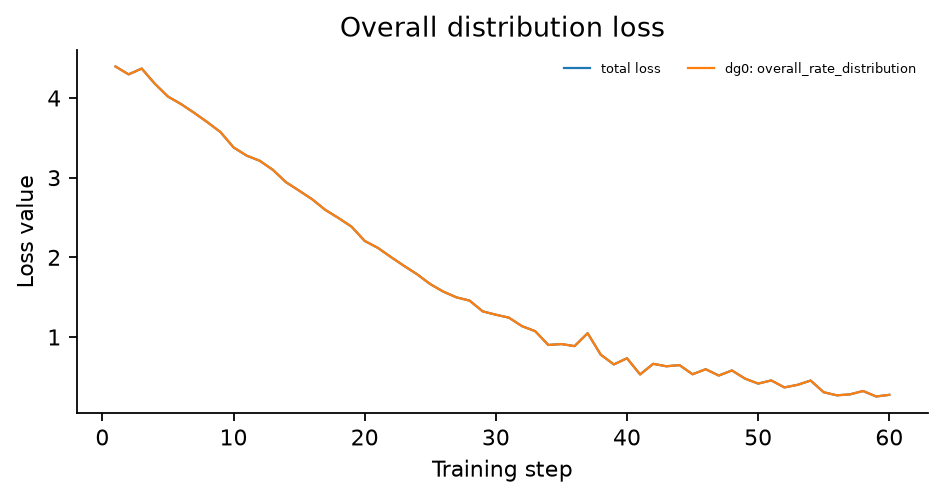

Spike count: 24392


,count,mean,median,std
firing_rate_hz,4838.0,5.041753,3.0,5.10436


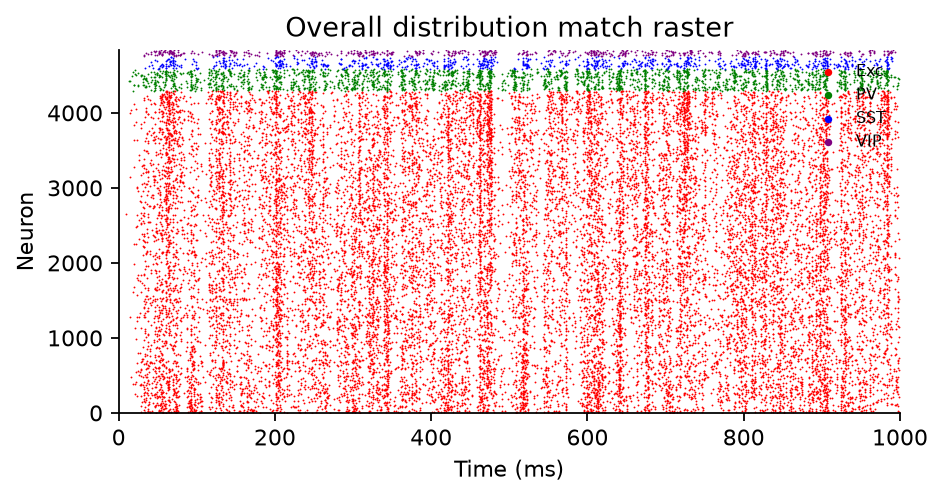

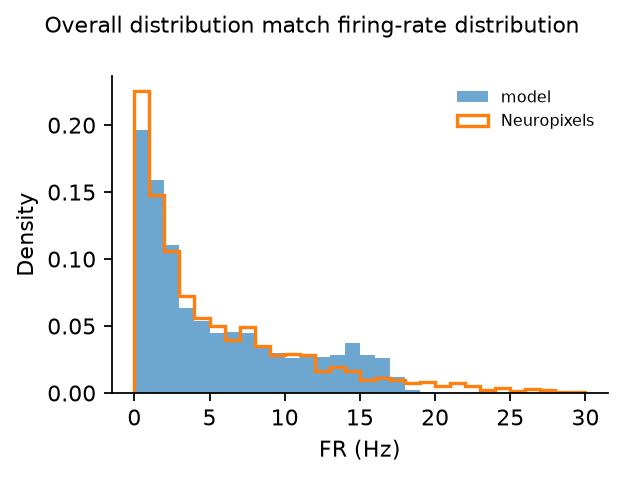

In [6]:
neuropixels_rates = ws.load_neuropixels_rates('Neuropixels_data/OSI_DSI_neuropixels_v4.csv.gz')

fig, axes = ws.plot_firing_rate_distribution(
    uniform_rates,
    neuropixels_rates=neuropixels_rates,
    target_rate=5.0,
    title='Uniform target compared with Neuropixels',
)
plt.show()

if RUN_SIMULATIONS:
    run_config('configs/config.l4.training.overall_distribution.json')
else:
    print('Skipping overall distribution training. Set RUN_SIMULATIONS = True to run it.')

ws.plot_loss_if_exists('training_callbacks_intro_l4_overall_distribution/losses.csv', 'Overall distribution loss')

overall_rates = ws.plot_intro_result(
    'output_intro_l4_overall_distribution/spikes.h5',
    network_dir='GLIF_network_l4_cutout/network',
    t_stop=1000.0,
    title='Overall distribution match',
    neuropixels_rates=neuropixels_rates,
)

### Matching distributions by cell type

The same overall distribution can hide mistakes across cell classes. This stage splits the model by cell type and compares each group with the matching Neuropixels target. This is the closest L4 example to the population-aware firing-rate matching used in the full V1 training configs.


,count,mean,median,std
cell_type,,,,
L4 Exc,4298,4.761750,3.0,4.729451
L4 PV,288,8.305556,11.0,6.794933
L4 SST,172,5.238372,0.0,7.254451
L4 VIP,80,7.912500,8.5,6.741509


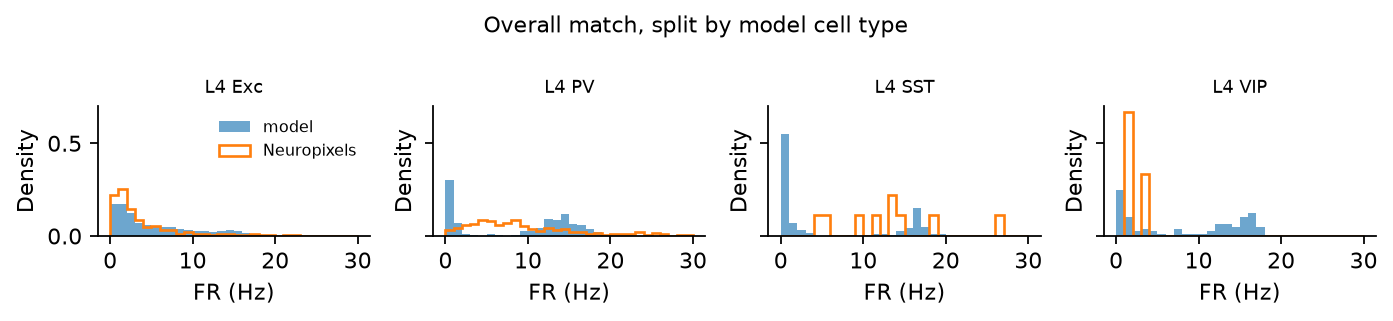

$ /local2/mmroot/envs/dpnet/bin/python run_dpointnet.py configs/config.l4.training.cell_type_distribution.json


I0000 00:00:1784141555.405753 1518823 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784141555.439674 1518823 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-15 11:52:38,280 [WARNING] Directory ./output_intro_l4_cell_type_distribution already exists.
2026-07-15 11:52:38,280 [INFO] Created log file
2026-07-15 11:52:38,280 [INFO] TensorFlow precision policy set to "mixed_float16" (compute_dtype=float16, variable_dtype=float32, requested_dtype=float16).


I0000 00:00:1784141558.590644 1518823 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1784141558.590921 1518823 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22437 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:65:00.0, compute capability: 8.6


2026-07-15 11:52:38,791 [INFO] Building "lgn_dg0" inputs for lgn
2026-07-15 11:52:38,891 [INFO] Building "bkg_random" inputs for bkg
Using custom neuropixels data file for FR loss: ./Neuropixels_data/OSI_DSI_neuropixels_v4.csv.gz
2026-07-15 11:52:39,050 [INFO] RNN.run() starting...
2026-07-15 11:52:39,050 [INFO] Building Model.


E0000 00:00:1784141559.933772 1518823 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


2026-07-15 11:52:41,235 [INFO] Training Model.
2026-07-15 11:52:41,241 [INFO] > Training Started @ 15-07-2026 11:52
2026-07-15 11:52:41,242 [INFO] >> Epoch 1/3 Started @ 15-07-2026 11:52


I0000 00:00:1784141561.287676 1518823 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1784141561.585927 1518992 service.cc:153] XLA service 0x7fb5840f5e80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784141561.585948 1518992 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3090, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.23.1)
I0000 00:00:1784141561.590946 1518992 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784141561.597611 1518992 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1784141561.694199 1518992 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2026-07-15 11:53:01,820 [INFO] >>> Epoch  1/ 3, Step  1/20 (run time: 20.55 s, Rate: 0.0050)
2026-07-15 11:53:01,821 [INFO] >>>   Loss: 6.7140 (dg0:   6.7140)
2026-07-15 11:53:01,830 [INFO] >>>   "GPU:0" Memory Used:   2.74 GiB, Free  20.95 GiB, Total  24.00 GiB.
2026-07-15 11:53:04,466 [INFO] >>> Epoch  1/ 3, Step  2/20 (run time: 2.61 s, Rate: 0.0050)
2026-07-15 11:53:04,466 [INFO] >>>   Loss: 6.0558 (dg0:   6.0558)
2026-07-15 11:53:04,475 [INFO] >>>   "GPU:0" Memory Used:   2.74 GiB, Free  20.95 GiB, Total  24.00 GiB.
2026-07-15 11:53:07,116 [INFO] >>> Epoch  1/ 3, Step  3/20 (run time: 2.62 s, Rate: 0.0051)
2026-07-15 11:53:07,116 [INFO] >>>   Loss: 6.3495 (dg0:   6.3495)
2026-07-15 11:53:07,138 [INFO] >>>   "GPU:0" Memory Used:   2.77 GiB, Free  20.92 GiB, Total  24.00 GiB.
2026-07-15 11:53:09,766 [INFO] >>> Epoch  1/ 3, Step  4/20 (run time: 2.60 s, Rate: 0.0050)
2026-07-15 11:53:09,767 [INFO] >>>   Loss: 5.4532 (dg0:   5.4532)
2026-07-15 11:53:09,788 [INFO] >>>   "GPU:0" Memory 

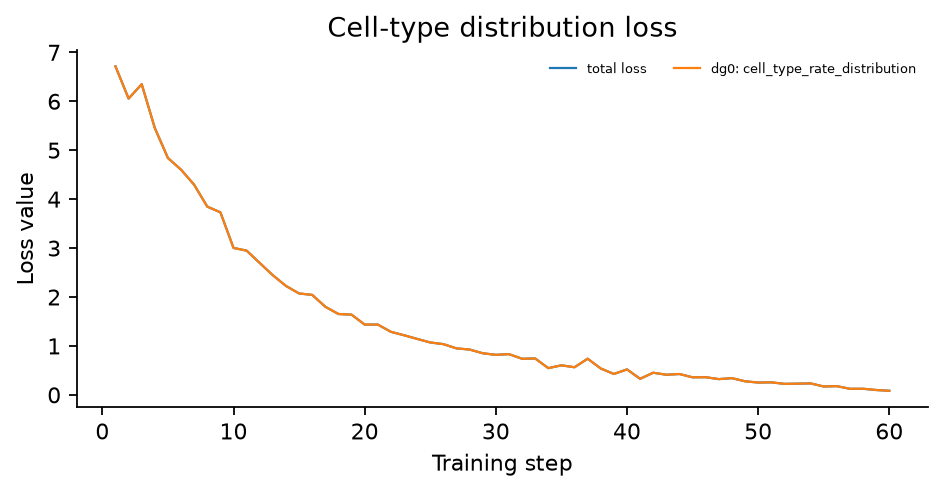

Spike count: 19813


,count,mean,median,std
cell_type,,,,
L4 Exc,4298,3.517217,2.0,4.079419
L4 PV,288,9.513889,8.0,6.450007
L4 SST,172,10.662791,11.0,5.584252
L4 VIP,80,1.525000,1.0,1.272643


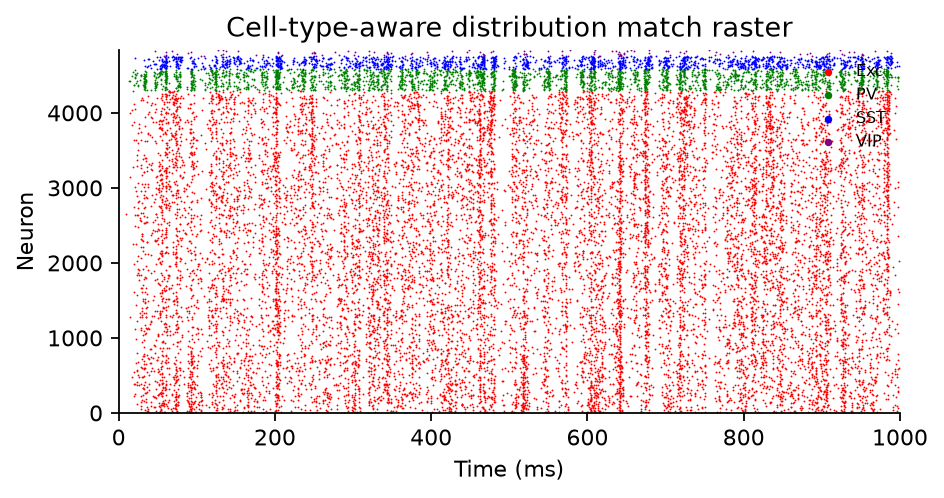

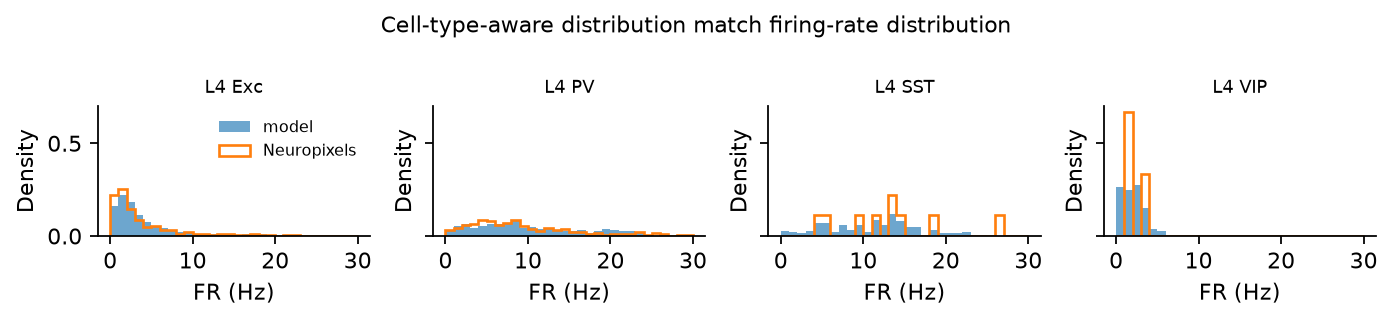

In [7]:
display(ws.summarize_firing_rates(overall_rates, by='cell_type'))
fig, axes = ws.plot_firing_rate_distribution(
    overall_rates,
    neuropixels_rates=neuropixels_rates,
    by='cell_type',
    title='Overall match, split by model cell type',
)
plt.show()

if RUN_SIMULATIONS:
    run_config('configs/config.l4.training.cell_type_distribution.json')
else:
    print('Skipping cell-type distribution training. Set RUN_SIMULATIONS = True to run it.')

ws.plot_loss_if_exists('training_callbacks_intro_l4_cell_type_distribution/losses.csv', 'Cell-type distribution loss')

cell_type_rates = ws.plot_intro_result(
    'output_intro_l4_cell_type_distribution/spikes.h5',
    network_dir='GLIF_network_l4_cutout/network',
    t_stop=1000.0,
    title='Cell-type-aware distribution match',
    neuropixels_rates=neuropixels_rates,
    by='cell_type',
)

### Scaling the same idea up to the whole V1 network

The compact L4 network is easy to train, but you can also train a much larger network with ~67k neurons. The rest of the notebook applies the same pattern to the 400-µm radius full V1 network.


## Inference before training

Now we move to the full V1 network. We first run two 500 ms drifting-grating conditions, 0 and 180 degrees, using fixed grating phase.


In [8]:
if RUN_SIMULATIONS:
    run_config('configs/config.v1.inference.dg0.json')
    run_config('configs/config.v1.inference.dg180.json')
else:
    print('Skipping full-network inference. Set RUN_SIMULATIONS = True to run it.')

$ /local2/mmroot/envs/dpnet/bin/python run_dpointnet.py configs/config.v1.inference.dg0.json


I0000 00:00:1784141783.942607 1520403 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784141783.977324 1520403 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-15 11:56:26,893 [WARNING] Directory ./output_inference_dg0 already exists.
2026-07-15 11:56:26,893 [INFO] Created log file
2026-07-15 11:56:26,894 [INFO] TensorFlow precision policy set to "mixed_float16" (compute_dtype=float16, variable_dtype=float32, requested_dtype=float16).


I0000 00:00:1784141787.216363 1520403 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1784141787.216611 1520403 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22437 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:65:00.0, compute capability: 8.6


2026-07-15 11:56:28,911 [INFO] Building "lgn_dg0" inputs for lgn
2026-07-15 11:56:29,012 [INFO] Building "bkg_random" inputs for bkg
2026-07-15 11:56:29,012 [INFO] RNN.run() starting...
2026-07-15 11:56:29,012 [INFO] Building Model.


...

2026-07-15 11:57:24,994 [INFO] Building "lgn_dg180" inputs for lgn
2026-07-15 11:57:25,093 [INFO] Building "bkg_random" inputs for bkg
2026-07-15 11:57:25,093 [INFO] RNN.run() starting...
2026-07-15 11:57:25,093 [INFO] Building Model.


/allen/aibha/workgroups/test/shinya.ito/dpointnet/bmtk-dpointnet/bmtk/simulator/dpointnet/network_adaptor.py:18: RuntimeWarning: overflow encountered in scalar multiply
  if np.iinfo(indices.dtype).max < max_ind * (max_ind + 1) :
E0000 00:00:1784141859.508465 1521031 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


2026-07-15 11:57:48,533 [INFO] Running Inference on Model (inference).


I0000 00:00:1784141868.577595 1521031 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1784141868.690718 1521245 service.cc:153] XLA service 0x7f1e8c0f8960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784141868.690738 1521245 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3090, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.23.1)
I0000 00:00:1784141868.695742 1521245 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784141868.702369 1521245 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1784141868.796830 1521245 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2026-07-15 11:58:14,349 [INFO] Saving Results to file.
2026-07-15 11:58:14,577 [INFO] RNN.run() completed.
Finished configs/config.v1.inference.dg180.json in 0.87 min


## Plotting network behavior

The spatial panels summarize firing rate across the x-z plane. Each panel bins neurons into 50 um squares from -400 to 400 um and shows the average firing over neurons within the bin. Rows show stimulus direction and layer: 0 degree L4, 0 degree L5, 180 degree L4, and 180 degree L5. Columns show five 100 ms windows across the 500 ms simulation. The color scale is fixed at 0-15 Hz so figures can be compared before and after training.


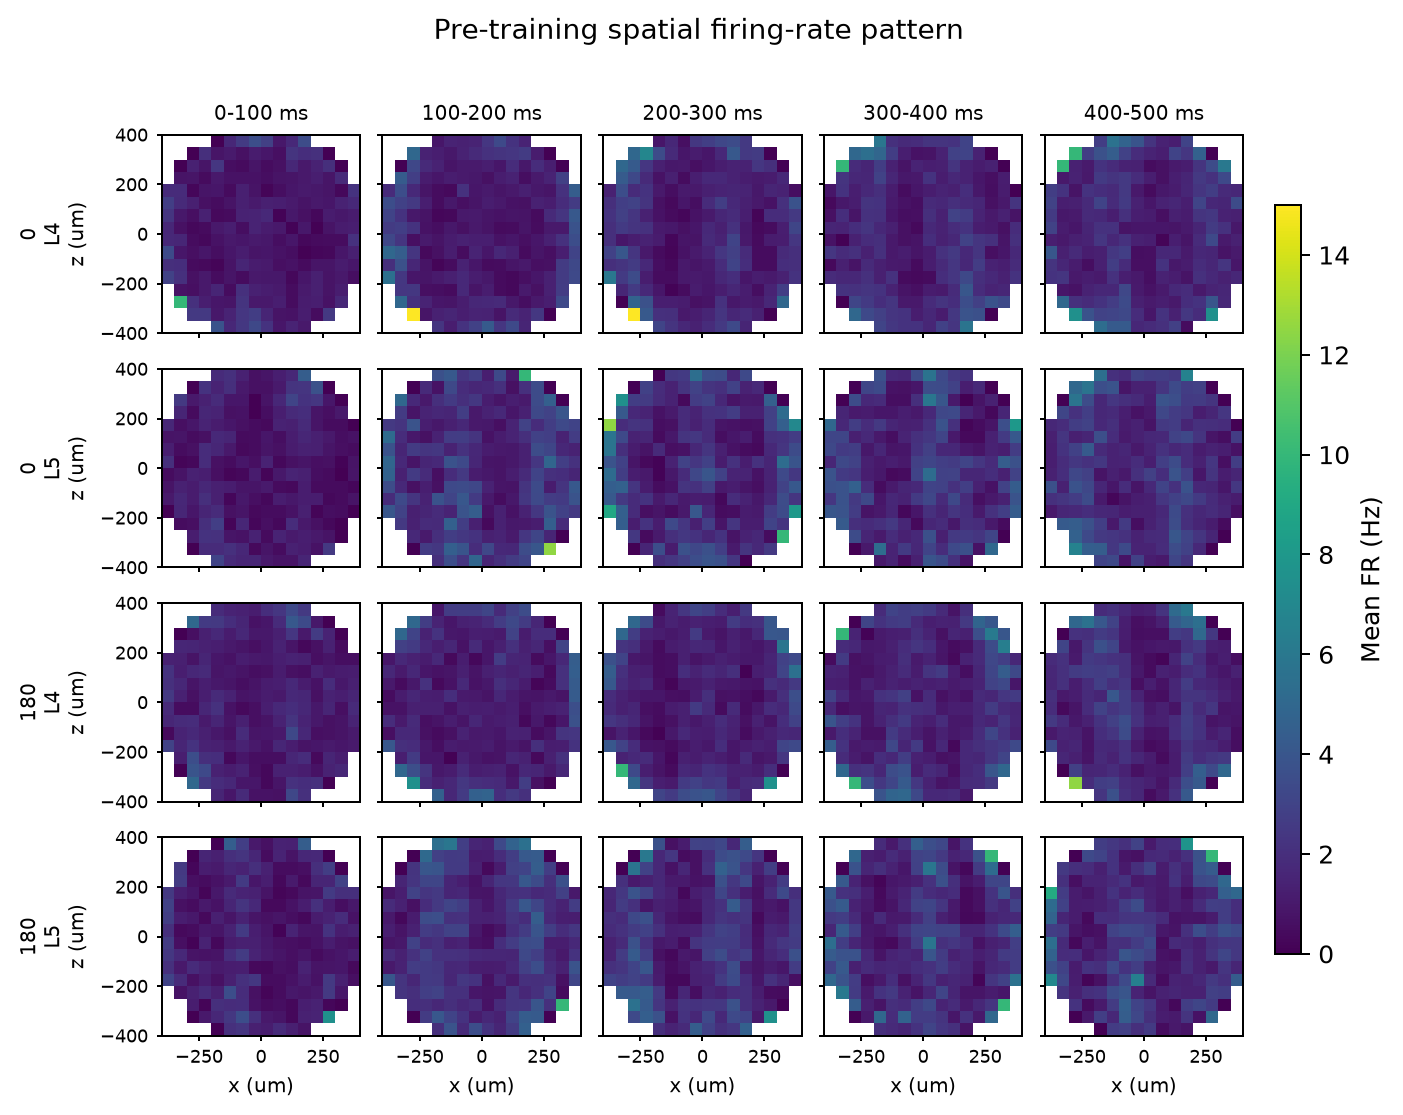

(<Figure size 1440x1170 with 21 Axes>,
 array([[<Axes: title={'center': '0-100 ms'}, ylabel='0\nL4\nz (um)'>,
         <Axes: title={'center': '100-200 ms'}>,
         <Axes: title={'center': '200-300 ms'}>,
         <Axes: title={'center': '300-400 ms'}>,
         <Axes: title={'center': '400-500 ms'}>],
        [<Axes: ylabel='0\nL5\nz (um)'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='180\nL4\nz (um)'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='x (um)', ylabel='180\nL5\nz (um)'>,
         <Axes: xlabel='x (um)'>, <Axes: xlabel='x (um)'>,
         <Axes: xlabel='x (um)'>, <Axes: xlabel='x (um)'>]], dtype=object))

In [9]:
ws.plot_spatial_results(
    {
        0: 'output_inference_dg0/spikes_dg0.h5',
        180: 'output_inference_dg180/spikes_dg180.h5',
    },
    network_dir='GLIF_network/network',
    title='Pre-training spatial firing-rate pattern',
)

## Training Step 1: adjust firing-rate distribution

Step 1 trains the full V1 network with the firing-rate distribution loss, voltage regularization, and recurrent weight regularization. It uses both 0 and 180 degree stimuli but does not yet add a spatial L5 preference. The goal is to move the full network toward a reasonable firing-rate regime before adding the left/right objective.

Note: Running this cell may take ~20 minutes on the AWS setup provided in the workshop. Training this network will consume most of the graphics-card memory available on the AWS machine. We suggest turning off other applications that consume graphics memory (Firefox, VND, etc.; you can check which applications are using graphics memory with the `nvidia-smi` command).


$ /local2/mmroot/envs/dpnet/bin/python run_dpointnet.py configs/config.v1.training.step1.fr.json


I0000 00:00:1784141896.997526 1521739 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784141897.031485 1521739 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-15 11:58:19,874 [WARNING] Directory ./output_training_step1_fr already exists.
2026-07-15 11:58:19,874 [INFO] Created log file
2026-07-15 11:58:19,875 [INFO] TensorFlow precision policy set to "mixed_float16" (compute_dtype=float16, variable_dtype=float32, requested_dtype=float16).


I0000 00:00:1784141900.178463 1521739 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1784141900.178706 1521739 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22437 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:65:00.0, compute capability: 8.6


2026-07-15 11:58:21,868 [INFO] Building "lgn_dg0" inputs for lgn
2026-07-15 11:58:21,968 [INFO] Building "lgn_dg180" inputs for lgn
2026-07-15 11:58:22,048 [INFO] Building "bkg_random" inputs for bkg


...

Using custom neuropixels data file for FR loss: ./Neuropixels_data/OSI_DSI_neuropixels_v4.csv.gz
Using custom neuropixels data file for FR loss: ./Neuropixels_data/OSI_DSI_neuropixels_v4.csv.gz


/allen/aibha/workgroups/test/shinya.ito/dpointnet/bmtk-dpointnet/bmtk/simulator/dpointnet/network_adaptor.py:18: RuntimeWarning: overflow encountered in scalar multiply
  if np.iinfo(indices.dtype).max < max_ind * (max_ind + 1) :
E0000 00:00:1784141923.598788 1521739 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Using custom neuropixels data file for FR loss: ./Neuropixels_data/OSI_DSI_neuropixels_v4.csv.gz
Using custom neuropixels data file for FR loss: ./Neuropixels_data/OSI_DSI_neuropixels_v4.csv.gz
2026-07-15 11:58:55,574 [INFO] RNN.run() starting...
2026-07-15 11:58:55,574 [INFO] Training Model.
2026-07-15 11:58:55,582 [INFO] > Training Started @ 15-07-2026 11:58
2026-07-15 11:58:55,583 [INFO] >> Epoch 1/5 Started @ 15-07-2026 11:58


I0000 00:00:1784141935.628401 1521739 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1784141935.765962 1521920 service.cc:153] XLA service 0x7fd74c0f4f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784141935.765982 1521920 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3090, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.23.1)
I0000 00:00:1784141935.770851 1521920 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784141935.777514 1521920 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1784141935.871291 1521920 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2026-07-15 11:59:17,882 [INFO] >>> Epoch  1/ 5, Step  1/10 (run time: 22.26 s, Rate: 0.0010)
2026-07-15 11:59:17,882 [INFO] >>>   Loss: 14.7634 (dg0  :   7.1299,   0.2673,   0.0000)
2026-07-15 11:59:17,883 [INFO] >>>                 (dg180:   7.0909,   0.2753,   0.0000)
2026-07-15 11:59:17,915 [INFO] >>>   "GPU:0" Memory Used:  10.89 GiB, Free  12.80 GiB, Total  24.00 GiB.
2026-07-15 11:59:22,767 [INFO] >>> Epoch  1/ 5, Step  2/10 (run time: 4.83 s, Rate: 0.0010)
2026-07-15 11:59:22,767 [INFO] >>>   Loss: 14.1113 (dg0  :   6.6976,   0.2743,   0.0214)
2026-07-15 11:59:22,767 [INFO] >>>                 (dg180:   6.8249,   0.2716,   0.0214)
2026-07-15 11:59:22,777 [INFO] >>>   "GPU:0" Memory Used:  11.18 GiB, Free  12.51 GiB, Total  24.00 GiB.
2026-07-15 11:59:27,659 [INFO] >>> Epoch  1/ 5, Step  3/10 (run time: 4.84 s, Rate: 0.0011)
2026-07-15 11:59:27,659 [INFO] >>>   Loss: 13.3805 (dg0  :   6.4570,   0.2753,   0.0324)
2026-07-15 11:59:27,659 [INFO] >>>                 (dg180:   6.3036,

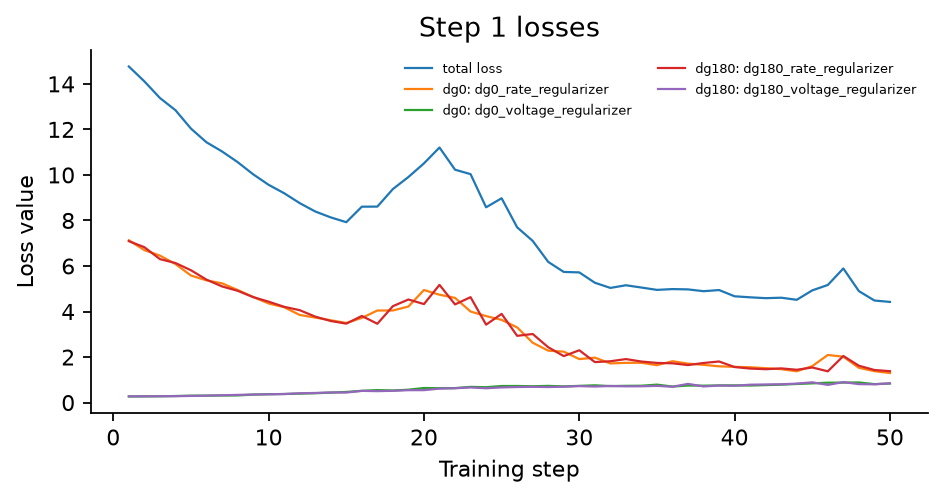

(<Figure size 960x480 with 1 Axes>,
 <Axes: title={'center': 'Step 1 losses'}, xlabel='Training step', ylabel='Loss value'>)

In [10]:
if RUN_SIMULATIONS:
    run_config('configs/config.v1.training.step1.fr.json')
else:
    print('Skipping Step 1 training. Set RUN_SIMULATIONS = True to run it.')

ws.plot_loss_if_exists('training_callbacks_step1_fr/losses.csv', 'Step 1 losses')

### Plot after Step 1

Step 1 writes post-training inference outputs for both drifting-grating directions. Plotting them with the same spatial layout as the baseline makes it easier to see whether firing rates changed for L4 and L5.

Note that there are other layers as well, but we are watching L4 and L5 for simplicity.

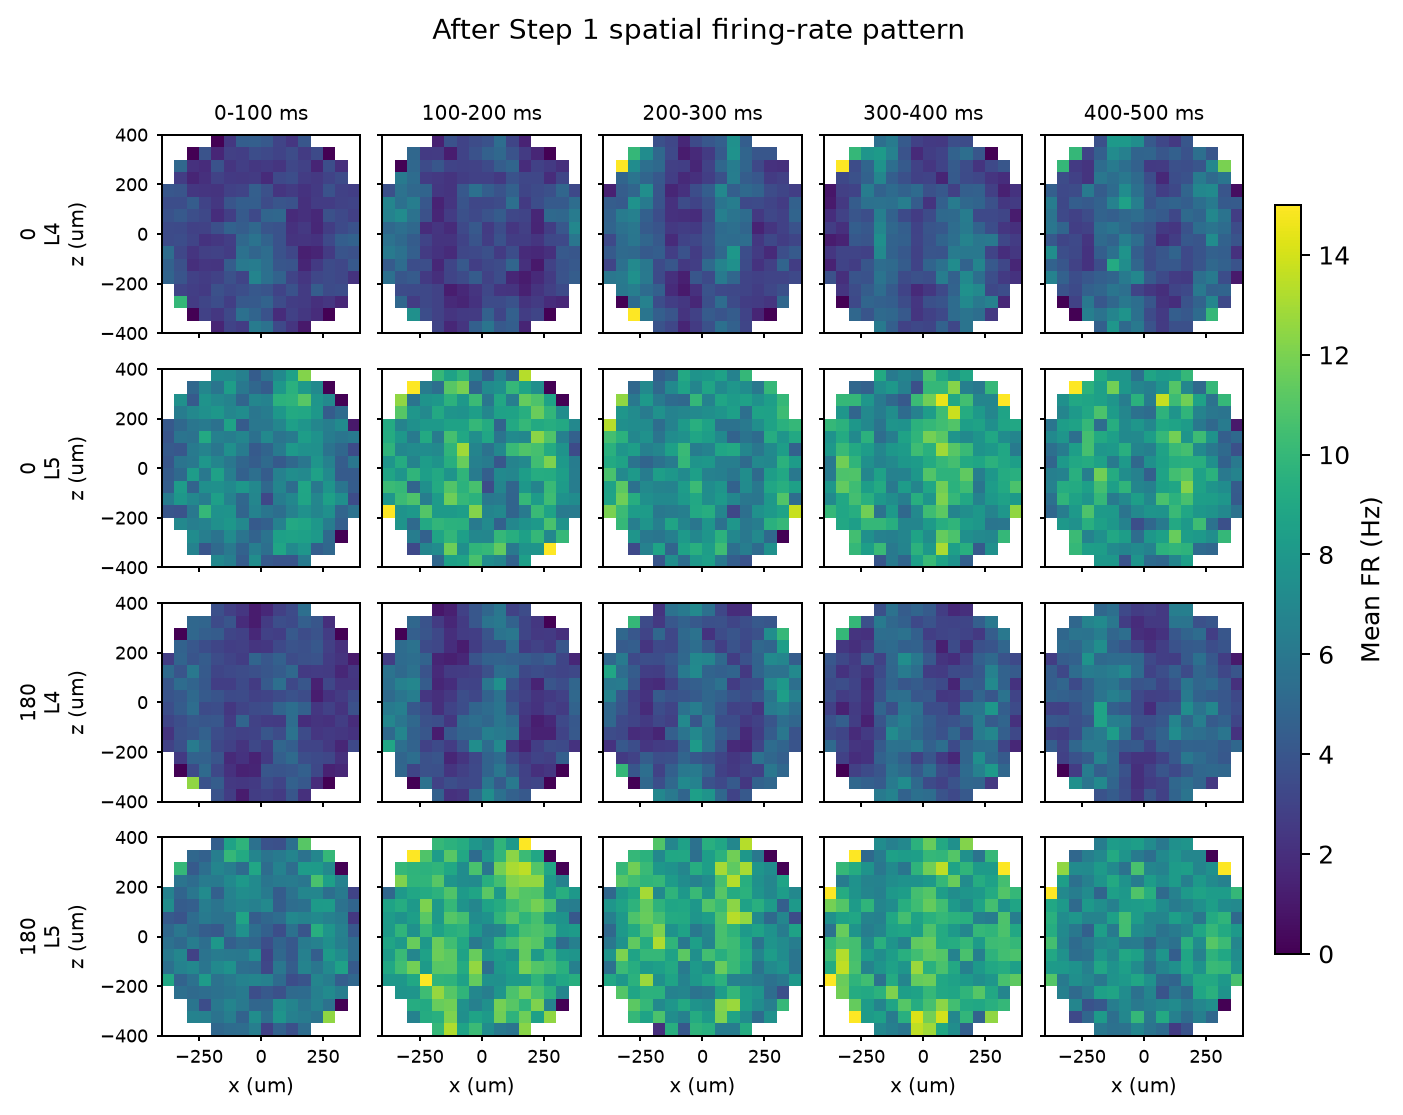

,condition,negative_z_hz,positive_z_hz,positive_minus_negative_hz
0,0,7.698630,7.704705,0.006075
1,180,8.006849,8.108848,0.101999


(<Figure size 1440x1170 with 21 Axes>,
 array([[<Axes: title={'center': '0-100 ms'}, ylabel='0\nL4\nz (um)'>,
         <Axes: title={'center': '100-200 ms'}>,
         <Axes: title={'center': '200-300 ms'}>,
         <Axes: title={'center': '300-400 ms'}>,
         <Axes: title={'center': '400-500 ms'}>],
        [<Axes: ylabel='0\nL5\nz (um)'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='180\nL4\nz (um)'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='x (um)', ylabel='180\nL5\nz (um)'>,
         <Axes: xlabel='x (um)'>, <Axes: xlabel='x (um)'>,
         <Axes: xlabel='x (um)'>, <Axes: xlabel='x (um)'>]], dtype=object))

In [11]:
ws.plot_spatial_results(
    {
        0: 'output_inference_step1_dg0/spikes_dg0.h5',
        180: 'output_inference_step1_dg180/spikes_dg180.h5',
    },
    network_dir='GLIF_network/network',
    title='After Step 1 spatial firing-rate pattern',
    show_l5_bias=True,
)

## Training Step 2: L5 left/right bias with z

Step 2 starts from the Step 1 trained weights. Now we want to introduce a non-trivial behavior in the network. We add an L5 spatial objective. For 0 degrees, the config rewards activity on one side of the z axis; for 180 degrees, the sign is reversed. The custom `L5ZAxisBiasLoss` used by this config is registered by `tutorial_losses.py` when the runner starts. Please take a look at the loss function. This loss function biases the firing rate along the z axis, depending on which direction the grating goes. The z axis is orthogonal to the stimulus direction, so this bias is unexpected without training. This is an artificial behavior introduced into the model simply to illustrate the capabilities of dpointnet. In real scientific applications, one would need to structure the loss functions according to specific experimental observations (or theoretical hypotheses), which will also likely require more conditions than just the two drifting grating directions considered here.

The diagram summarizes this population-level manipulation: the two grating directions are paired with targets on opposite sides of L5. The highlighted regions indicate where the custom loss rewards activity; they are illustrative targets rather than experimentally observed responses.

<img src="images/l5_spatial_manipulation.png" alt="Opposite layer 5 spatial targets for 0 and 180 degree gratings" width="850">

The training may take ~30 minutes to complete on the AWS setup provided in the workshop.

$ /local2/mmroot/envs/dpnet/bin/python run_dpointnet.py configs/config.v1.training.step2.l5_z.json


I0000 00:00:1784142272.082352 1523510 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784142272.116277 1523510 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-15 12:04:35,040 [WARNING] Directory ./output_training_step2_l5_z already exists.
2026-07-15 12:04:35,040 [INFO] Created log file
2026-07-15 12:04:35,041 [INFO] TensorFlow precision policy set to "mixed_float16" (compute_dtype=float16, variable_dtype=float32, requested_dtype=float16).


I0000 00:00:1784142275.362228 1523510 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1784142275.362471 1523510 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22437 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:65:00.0, compute capability: 8.6


2026-07-15 12:04:36,781 [INFO] Building "lgn_dg0" inputs for lgn
2026-07-15 12:04:36,879 [INFO] Building "lgn_dg180" inputs for lgn
2026-07-15 12:04:36,959 [INFO] Building "bkg_random" inputs for bkg


...

Using custom neuropixels data file for FR loss: ./Neuropixels_data/OSI_DSI_neuropixels_v4.csv.gz


/allen/aibha/workgroups/test/shinya.ito/dpointnet/bmtk-dpointnet/bmtk/simulator/dpointnet/network_adaptor.py:18: RuntimeWarning: overflow encountered in scalar multiply
  if np.iinfo(indices.dtype).max < max_ind * (max_ind + 1) :
E0000 00:00:1784142292.055094 1523510 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Using custom neuropixels data file for FR loss: ./Neuropixels_data/OSI_DSI_neuropixels_v4.csv.gz
2026-07-15 12:05:04,001 [INFO] RNN.run() starting...
2026-07-15 12:05:04,001 [INFO] Training Model.
2026-07-15 12:05:04,009 [INFO] > Training Started @ 15-07-2026 12:05
2026-07-15 12:05:04,010 [INFO] >> Epoch 1/10 Started @ 15-07-2026 12:05


I0000 00:00:1784142304.055316 1523510 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1784142304.192908 1523671 service.cc:153] XLA service 0x7f5eb40f65e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784142304.192928 1523671 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3090, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.23.1)
I0000 00:00:1784142304.197942 1523671 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784142304.204823 1523671 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1784142304.299112 1523671 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2026-07-15 12:05:24,390 [INFO] >>> Epoch  1/10, Step  1/10 (run time: 20.35 s, Rate: 0.0041)
2026-07-15 12:05:24,390 [INFO] >>>   Loss: 3.9938 (dg0  :  -0.0493,   1.1511,   0.8604,   0.0000)
2026-07-15 12:05:24,390 [INFO] >>>                (dg180:   0.0725,   1.1052,   0.8539,   0.0000)
2026-07-15 12:05:24,411 [INFO] >>>   "GPU:0" Memory Used:  12.74 GiB, Free  10.95 GiB, Total  24.00 GiB.
2026-07-15 12:05:29,588 [INFO] >>> Epoch  1/10, Step  2/10 (run time: 5.15 s, Rate: 0.0042)
2026-07-15 12:05:29,588 [INFO] >>>   Loss: 3.6858 (dg0  :   0.0335,   1.0130,   0.8269,   0.0333)
2026-07-15 12:05:29,588 [INFO] >>>                (dg180:   0.0195,   0.9464,   0.7801,   0.0333)
2026-07-15 12:05:29,610 [INFO] >>>   "GPU:0" Memory Used:  12.74 GiB, Free  10.95 GiB, Total  24.00 GiB.
2026-07-15 12:05:34,770 [INFO] >>> Epoch  1/10, Step  3/10 (run time: 5.11 s, Rate: 0.0042)
2026-07-15 12:05:34,770 [INFO] >>>   Loss: 3.7752 (dg0  :   0.0184,   0.8884,   0.8314,   0.0375)
2026-07-15 12:05:34,770

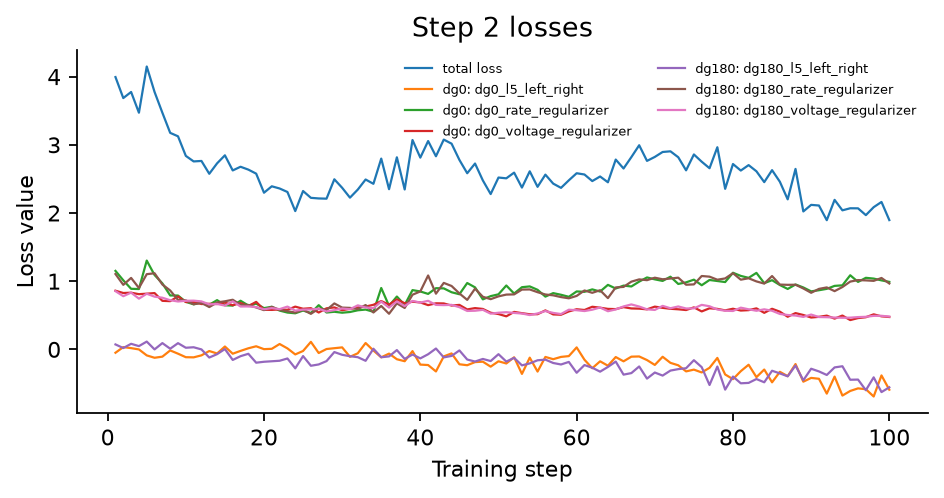

(<Figure size 960x480 with 1 Axes>,
 <Axes: title={'center': 'Step 2 losses'}, xlabel='Training step', ylabel='Loss value'>)

In [12]:
if RUN_SIMULATIONS:
    run_config('configs/config.v1.training.step2.l5_z.json')
else:
    print('Skipping Step 2 training. Set RUN_SIMULATIONS = True after Step 1 weights exist.')

ws.plot_loss_if_exists('training_callbacks_step2_l5_z/losses.csv', 'Step 2 losses')

### Plot after Step 2

Step 2 writes its own post-training inference outputs. These panels should be compared with the baseline and Step 1 panels. Indeed, neurons with z > 0 are firing more for 0 degree stimulus and vice versa. The side-bias summary reports the mean L5 firing rate on negative and positive z sides for each stimulus direction.


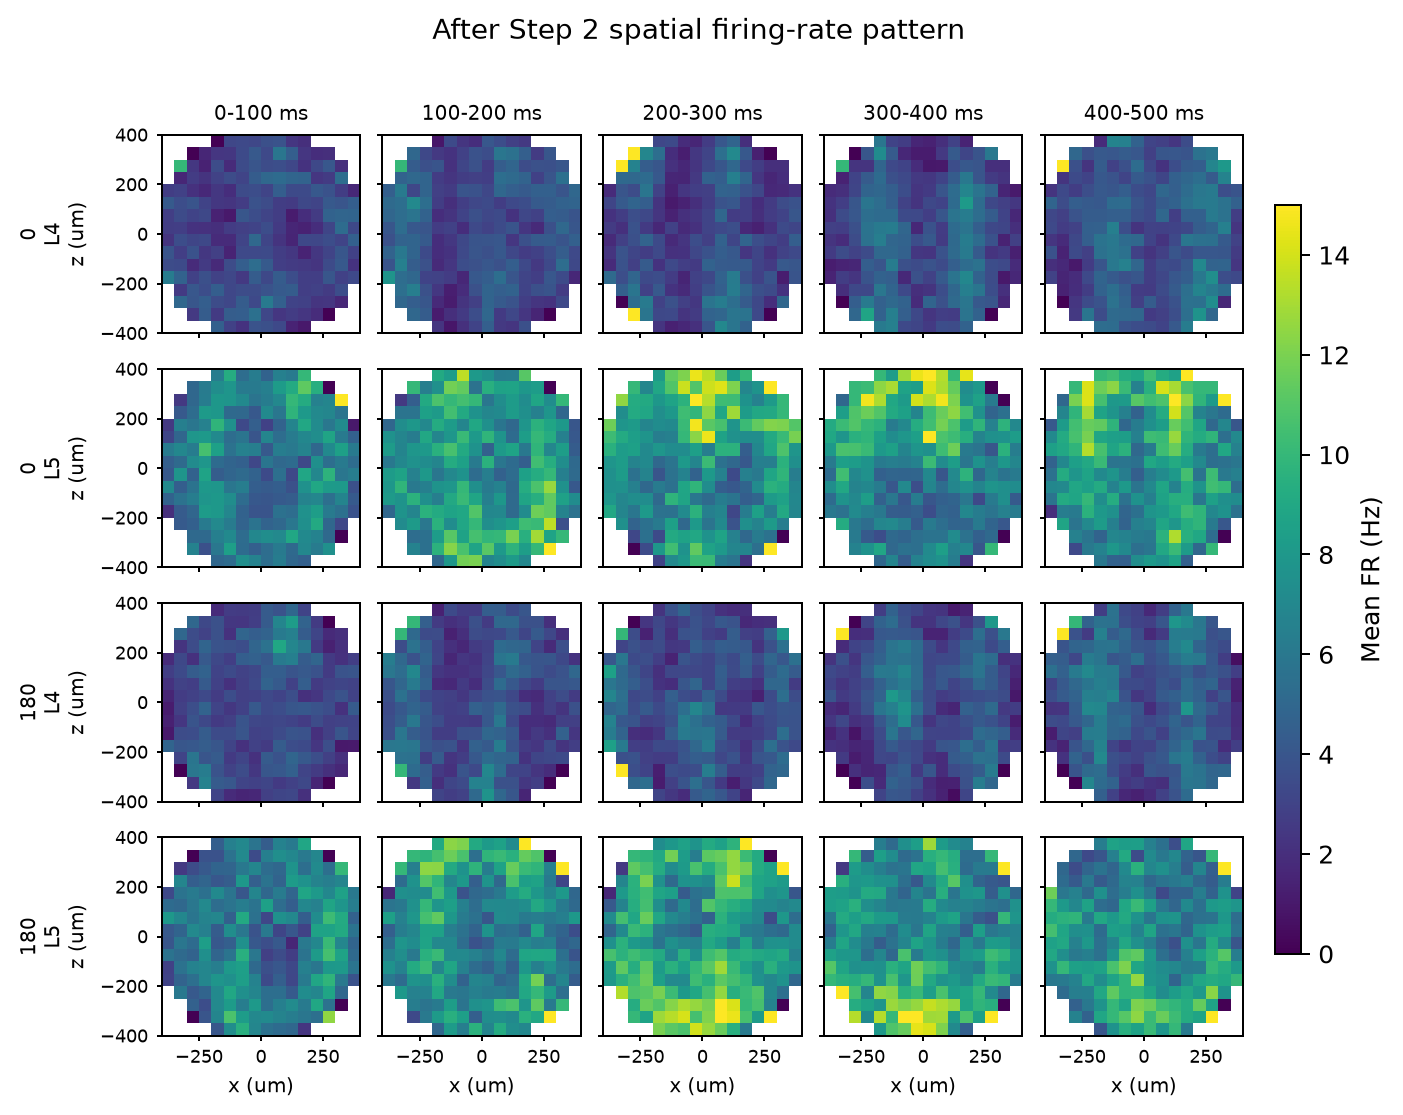

,condition,negative_z_hz,positive_z_hz,positive_minus_negative_hz
0,0,6.984589,8.352879,1.36829
1,180,8.145890,7.165730,-0.98016


(<Figure size 1440x1170 with 21 Axes>,
 array([[<Axes: title={'center': '0-100 ms'}, ylabel='0\nL4\nz (um)'>,
         <Axes: title={'center': '100-200 ms'}>,
         <Axes: title={'center': '200-300 ms'}>,
         <Axes: title={'center': '300-400 ms'}>,
         <Axes: title={'center': '400-500 ms'}>],
        [<Axes: ylabel='0\nL5\nz (um)'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='180\nL4\nz (um)'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='x (um)', ylabel='180\nL5\nz (um)'>,
         <Axes: xlabel='x (um)'>, <Axes: xlabel='x (um)'>,
         <Axes: xlabel='x (um)'>, <Axes: xlabel='x (um)'>]], dtype=object))

In [13]:
ws.plot_spatial_results(
    {
        0: 'output_inference_step2_dg0/spikes_dg0.h5',
        180: 'output_inference_step2_dg180/spikes_dg180.h5',
    },
    network_dir='GLIF_network/network',
    title='After Step 2 spatial firing-rate pattern',
    show_l5_bias=True,
)

## Extra credit

The L5 spatial objective can create the desired left/right contrast while also changing total L5 activity. How would you modify the objective so that the network learns a spatial contrast without simply increasing or decreasing total firing? One useful direction is to compare normalized activity between sides, or add a paired penalty that keeps total L5 firing close to its Step 1 value while rewarding the spatial difference.


---

## Next Steps

In this section of the tutorial we used a number of built-in DPointNet functionalities designed for training cortical networks with visual stimuli. But DPointNet also provides the ability for users to create custom modules and functions to train across a variety of brain areas and modalities. The next tutorial shows how one might customize their training, using auditory processing as an example:

[**Proceed to Chapter 7.3**](../Ch7.3_gamma/dpointnet_gamma_tutorial.ipynb)